BFS Traversal: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


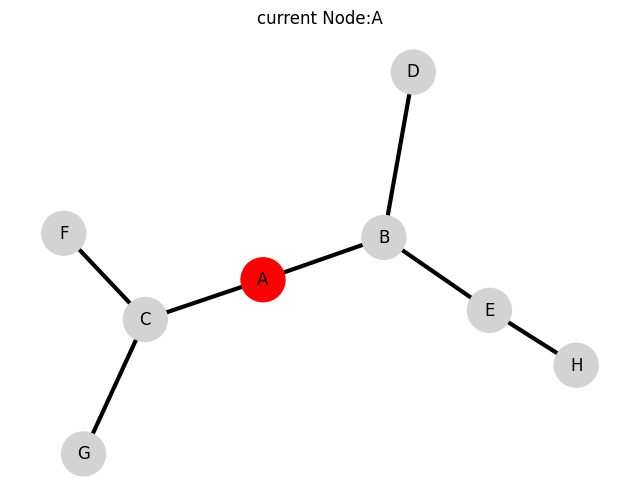

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from collections import deque
from IPython.display import HTML
G=nx.Graph()
edges=[
    ('A','B'),('A','C'),
    ('B','D'),('B','E'),
    ('C','F'),('C','G'),
    ('E','H'),
]
G.add_edges_from(edges)
visited=[]
parent={}
queue=deque(['A'])
while queue:
  node=queue.popleft()
  if node not in visited:
    visited.append(node)
    for neighbour in sorted(G.neighbors(node)):
      if neighbour not in visited and neighbour not in queue:
        parent[neighbour]=node
        queue.append(neighbour)
print("BFS Traversal:",visited)
pos=nx.spring_layout(G,seed=5)
fig,ax=plt.subplots(figsize=(8,6))
def update(frame):
  ax.clear()
  visited_now=visited[:frame+1]
  node_colors=[
    'red'if n in visited_now else 'lightgray'
    for n in G.nodes()
    ]
  edge_colors=[]
  for u,v in G.edges():
     if((v in parent and parent[v]==u and v in visited_now)
  or
        (u in parent and parent[u]==v and u in visited_now)):
         edge_colors.append('green')
     else:
         edge_colors.append('black')
  nx.draw(G,pos,ax=ax,
        with_labels=True,
        node_size=1000,
        node_color=node_colors,
        edge_color=edge_colors,
        width=3)
  ax.set_title(
    f"current Node:{visited[frame]}"
)
ani=FuncAnimation(
    fig,update,
    frames=len(visited),
    interval=1200,
    repeat=False
)
HTML(ani.to_jshtml())